In [37]:

import pandas as pd
from sklearn.model_selection import train_test_split
import warnings
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score

from sklearn.utils import shuffle
from sklearn.preprocessing import LabelEncoder
import pickle
warnings.filterwarnings(action="ignore")

In [38]:
df=pd.read_csv('Car_Hacking.csv')
df.head()

,CAN ID,DATA[0],DATA[1],DATA[2],DATA[3],DATA[4],DATA[5],DATA[6],DATA[7],Label
0,1201,41,39,39,35,0,0,0,154,R
1,809,64,187,127,20,17,32,0,20,R
2,1349,216,0,0,136,0,0,0,0,R
3,1201,41,39,39,35,0,0,0,154,R
4,2,0,0,0,0,0,3,2,228,R


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 818440 entries, 0 to 818439
Data columns (total 10 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   CAN ID   818440 non-null  int64 
 1   DATA[0]  818440 non-null  int64 
 2   DATA[1]  818440 non-null  int64 
 3   DATA[2]  818440 non-null  int64 
 4   DATA[3]  818440 non-null  int64 
 5   DATA[4]  818440 non-null  int64 
 6   DATA[5]  818440 non-null  int64 
 7   DATA[6]  818440 non-null  int64 
 8   DATA[7]  818440 non-null  int64 
 9   Label    818440 non-null  object
dtypes: int64(9), object(1)
memory usage: 62.4+ MB


In [40]:
df.isna().sum()

CAN ID     0
DATA[0]    0
DATA[1]    0
DATA[2]    0
DATA[3]    0
DATA[4]    0
DATA[5]    0
DATA[6]    0
DATA[7]    0
Label      0
dtype: int64

In [41]:
maps = {}
def find_category_mappings(df, variable):
    return {k: i for i, k in enumerate(df[variable].unique())}

def integer_encode(df, variable, ordinal_mapping):
    df[variable] =  df[variable].map(ordinal_mapping)
    maps[variable] = mappings
    
for variable in df.columns:
    if df[variable].dtype == "object":
        mappings = find_category_mappings(df, variable)
        integer_encode(df, variable,  mappings)
        maps[variable] = mappings
maps        

{'Label': {'R': 0, 'DoS': 1, 'Fuzzy': 2, 'RPM': 3, 'gear': 4}}

In [42]:
with open("map.txt", "w") as file:
    file.write(str(maps))

In [43]:
df.head()

,CAN ID,DATA[0],DATA[1],DATA[2],DATA[3],DATA[4],DATA[5],DATA[6],DATA[7],Label
0,1201,41,39,39,35,0,0,0,154,0
1,809,64,187,127,20,17,32,0,20,0
2,1349,216,0,0,136,0,0,0,0,0
3,1201,41,39,39,35,0,0,0,154,0
4,2,0,0,0,0,0,3,2,228,0


In [44]:
df.tail()

,CAN ID,DATA[0],DATA[1],DATA[2],DATA[3],DATA[4],DATA[5],DATA[6],DATA[7],Label
818435,848,5,32,52,104,117,0,0,12,0
818436,1088,255,0,0,0,255,134,9,0,0
818437,848,5,32,100,104,117,0,0,92,0
818438,1349,216,90,0,137,0,0,0,0,0
818439,790,5,33,48,10,33,30,0,111,0


In [45]:
x=df.iloc[:,:-1]
y=df.iloc[:,-1:]

In [46]:
x.head()

,CAN ID,DATA[0],DATA[1],DATA[2],DATA[3],DATA[4],DATA[5],DATA[6],DATA[7]
0,1201,41,39,39,35,0,0,0,154
1,809,64,187,127,20,17,32,0,20
2,1349,216,0,0,136,0,0,0,0
3,1201,41,39,39,35,0,0,0,154
4,2,0,0,0,0,0,3,2,228


In [47]:
y.head()

,Label
0,0
1,0
2,0
3,0
4,0


In [48]:
from imblearn.over_sampling import RandomOverSampler# balancing package
ros=RandomOverSampler()

In [49]:
xres,yres = ros.fit_resample(x, y)

In [50]:
x.head()

,CAN ID,DATA[0],DATA[1],DATA[2],DATA[3],DATA[4],DATA[5],DATA[6],DATA[7]
0,1201,41,39,39,35,0,0,0,154
1,809,64,187,127,20,17,32,0,20
2,1349,216,0,0,136,0,0,0,0
3,1201,41,39,39,35,0,0,0,154
4,2,0,0,0,0,0,3,2,228


In [51]:
yres.head()

,Label
0,0
1,0
2,0
3,0
4,0


In [132]:
df.iloc[2:3].to_csv('test0.csv')
df.iloc[102:103].to_csv('test1.csv')
df.iloc[182262:182263].to_csv('test2.csv')
df.iloc[597960:597961].to_csv('test3.csv')
df.iloc[477:478].to_csv('test4.csv')

df.iloc[149:150].to_csv('test5.csv')
df.iloc[354:355].to_csv('test6.csv')
df.iloc[374:375].to_csv('test7.csv')

In [53]:
from collections import Counter

In [54]:
Counter(y)

Counter({'Label': 1})

In [55]:
from imblearn.over_sampling import RandomOverSampler

In [56]:
ros = RandomOverSampler(random_state=42)
X_res, y_res = ros.fit_resample(x, y)

In [57]:
Counter(y_res)

Counter({'Label': 1})

In [58]:
from sklearn.model_selection import train_test_split

In [59]:
X_res

,CAN ID,DATA[0],DATA[1],DATA[2],DATA[3],DATA[4],DATA[5],DATA[6],DATA[7]
0,1201,41,39,39,35,0,0,0,154
1,809,64,187,127,20,17,32,0,20
2,1349,216,0,0,136,0,0,0,0
3,1201,41,39,39,35,0,0,0,154
4,2,0,0,0,0,0,3,2,228
...,...,...,...,...,...,...,...,...,...
3509155,1087,1,69,96,255,107,0,0,0
3509156,1087,1,69,96,255,107,0,0,0
3509157,1087,1,69,96,255,107,0,0,0
3509158,1087,1,69,96,255,107,0,0,0


In [60]:

x_train,x_test,y_train,y_test=train_test_split(X_res, y_res,train_size=0.8)
x_train.head()

,CAN ID,DATA[0],DATA[1],DATA[2],DATA[3],DATA[4],DATA[5],DATA[6],DATA[7]
3363388,1087,1,69,96,255,107,0,0,0
884494,0,0,0,0,0,0,0,0,0
602829,809,220,190,127,20,17,32,0,20
2482139,790,69,41,36,255,41,36,0,255
1376147,0,0,0,0,0,0,0,0,0


In [61]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(x_train,y_train)

LogisticRegression()

In [62]:
y_pred=lr.predict(x_test)
y_pred

array([4, 1, 2, ..., 3, 3, 2], dtype=int64)

In [63]:
from sklearn.metrics import accuracy_score
ac=accuracy_score(y_test,y_pred)
ac

0.9538066089890458

In [64]:
from sklearn.tree import DecisionTreeClassifier
dtc_clf=DecisionTreeClassifier(max_depth=5,random_state=10)
dtc_clf.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=5, random_state=10)

In [65]:
y_predict=dtc_clf.predict(x_test)
y_predict

array([4, 1, 2, ..., 3, 3, 2], dtype=int64)

In [66]:
from sklearn.metrics import accuracy_score
ac=accuracy_score(y_test,y_predict)
ac

0.9811450603563245

In [67]:
import joblib

In [68]:
joblib.dump(dtc_clf,"ds1.joblib")

['ds1.joblib']

In [69]:
from sklearn.ensemble import RandomForestClassifier
rmf=RandomForestClassifier(max_depth=4,random_state=40)
rmf_clf=rmf.fit(x_train,y_train)

In [70]:
y_predict1=rmf_clf.predict(x_test)
y_predict1

array([4, 1, 2, ..., 3, 3, 2], dtype=int64)

In [71]:
from sklearn.metrics import accuracy_score
ac1=accuracy_score(y_test,y_predict1)
ac1

0.988340514539092

Confusion Matrix:
[[132564      0   7706      0      0]
 [     0 140739      0      0      0]
 [   477      0 139548      0      0]
 [     0      0      0 140459      0]
 [     0      0      0      0 140339]]

 Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.97    140270
           1       1.00      1.00      1.00    140739
           2       0.95      1.00      0.97    140025
           3       1.00      1.00      1.00    140459
           4       1.00      1.00      1.00    140339

    accuracy                           0.99    701832
   macro avg       0.99      0.99      0.99    701832
weighted avg       0.99      0.99      0.99    701832



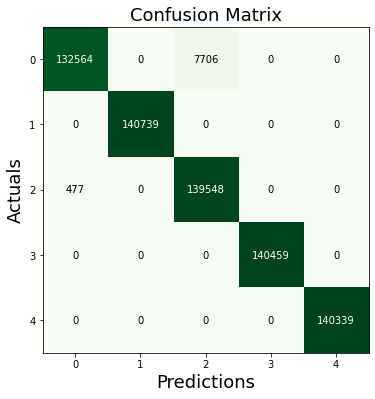

In [72]:

print("Confusion Matrix:")
cm=confusion_matrix(y_test,y_predict1)
print(cm)

print("\n Classification Report:")
print(classification_report(y_test,y_predict1))

fig, ax = plot_confusion_matrix(conf_mat=cm , figsize=(6, 6), cmap=plt.cm.Greens)
plt.xlabel('Predictions', fontsize=18)
plt.ylabel('Actuals', fontsize=18)
plt.title('Confusion Matrix', fontsize=18)
plt.show()

In [73]:
scores = cross_val_score(dtc_clf, x, y, cv=5)

# Print the cross-validation scores
print("Cross-Validation Scores:", scores)

# Mean score refers to the average score obtained from a set of scores. (moyenne)
print("Mean Score:", scores.mean())

Cross-Validation Scores: [0.98931504 0.98921118 0.98959606 0.98947999 0.98951053]
Mean Score: 0.9894225599921803


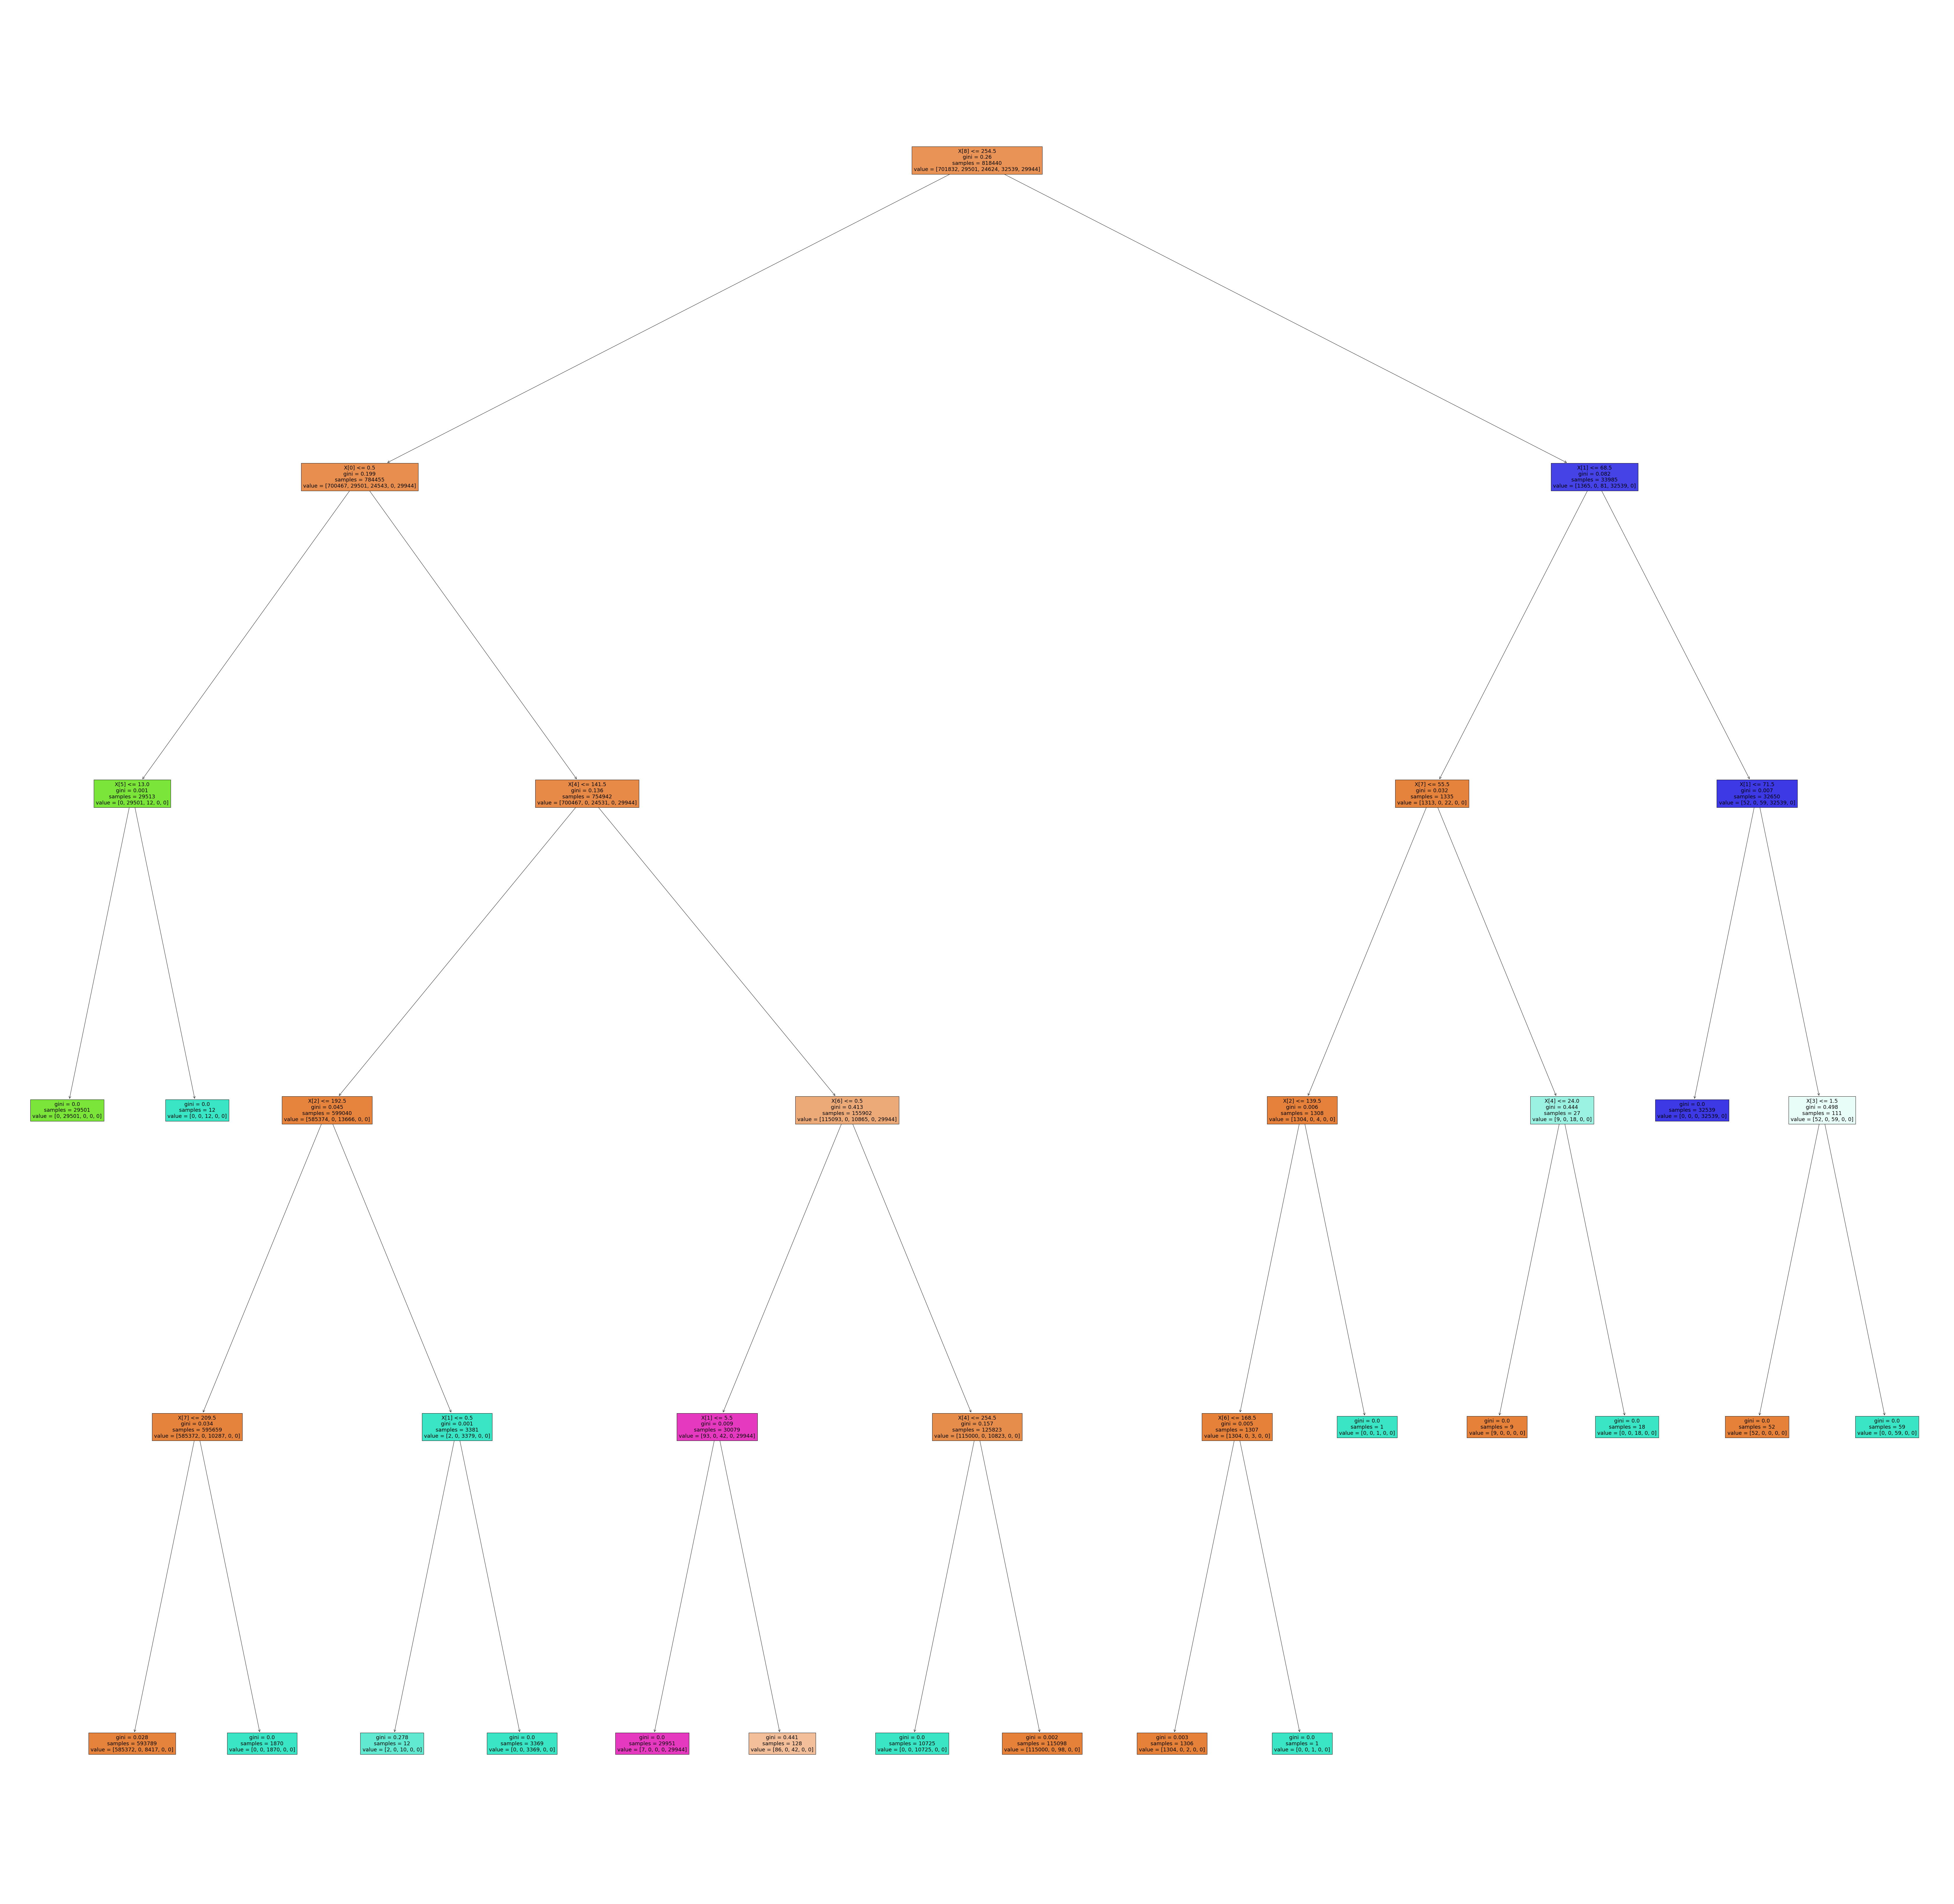

In [74]:

dtc_clf.fit(x, y)

plt.figure(figsize=(120, 120))
plot_tree(dtc_clf, filled=True)
plt.show
plt.savefig('dreeroots.png')

# testing

In [75]:
import pandas as pd
from tensorflow.keras.models import load_model
import numpy as np
import joblib

In [76]:

ds=joblib.load("ds1.joblib")

In [130]:
d1=pd.read_csv("test4.csv")
d1

,Unnamed: 0,CAN ID,DATA[0],DATA[1],DATA[2],DATA[3],DATA[4],DATA[5],DATA[6],DATA[7],Label


In [131]:
df1=d1.iloc[:,1:-1]


In [126]:
pred=ds.predict(df1)
pred[0]

1

In [123]:
#{'R': 0, 'DoS': 1, 'Fuzzy': 2, 'RPM': 3, 'gear': 4}
if pred[0]==0:
    result="Ready,"
elif pred[0]==1:
    result="Denial of Service attacks"
elif pred[0]==2:
    result='Fuzzy'
elif pred[0]==3:
    result="Revolutions Per Minute"
elif pred[0]==4:
    result='gear'    
print(result)    

Denial of Service attacks
